<a href="https://colab.research.google.com/github/valperezg02/Analitica-de-Negocios/blob/main/Reto_Parcial_1_Valeria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Caso de Estudio**

Una entidad del sector salud quiere implementar un modelo para clasificar los pacientes que poseen diabetes, usando diferentes variables de salud.

Se utilizará la base de datos: “Pima Indians Diabetes Database”

Se quiere comparar el modelo utilizando los siguientes métodos:

* Naive Bayes
* Árbol de Decisión
* Clustering K-Means

El objetivo es identificar cuál modelo realiza el mejor análisis según los resultados obtenidos.

Para este proceso se usarán las siguientes variables:

* **Pregnancies:** es el número de embarazos que ha tenido el paciente.
* **Glucose:** muestra el nivel de glucosa en la sangre. Es una variable importante porque niveles altos suelen estar relacionados con la diabetes.
* **BloodPressure:** indica la presión arterial del paciente.
* **SkinThickness:** indica el grosor del pliegue cutáneo, utilizado como una medida relacionada con la composición corporal.
* **Insulin:** indica el nivel de insulina en la sangre. Esta variable también está relacionada con la presencia de diabetes.
* **BMI:** indica el índice de masa corporal del paciente.
* **DiabetesPedigreeFunction:** muestra el historial hereditario o predisposición genética a la diabetes.
* **Age:** indica la edad del paciente.

Se busca clasificar correctamente a los pacientes que poseen o no diabetes, identificar las variables que tienen mayor relación con la enfermedad, analizar el comportamiento de los modelos y determinar cuál de ellos es el más adecuado para este caso de estudio.



0. Se procede con la carga de librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

import seaborn as sns
from sklearn.cluster import KMeans

1. Se cargan los datos de trabajo de la base de datos "diabetes" y se hace la correlación

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


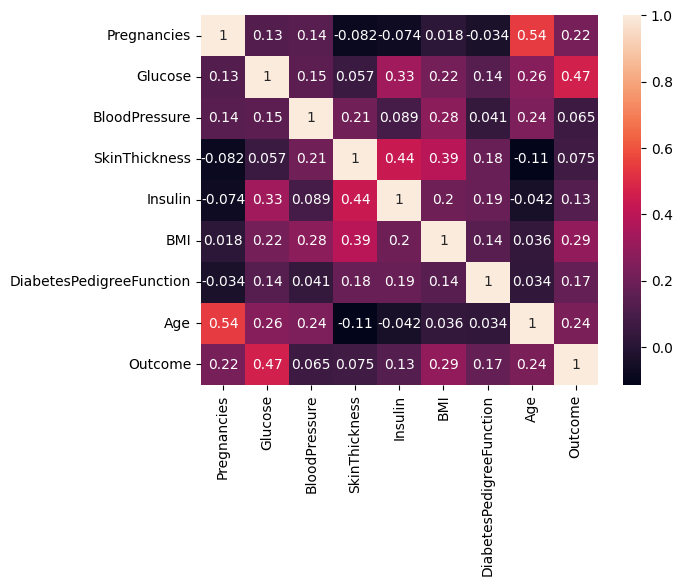

In [ ]:
nxl = '/content/diabetes.csv'
XDB = pd.read_csv(nxl)

XD = XDB.iloc[:,0:8]
yd = XDB.iloc[:,8]

display(XD)
display(yd)

XDB2 = XDB.iloc[:,[0,1,2,3,4,5,6,7,8]]
sns.heatmap(XDB2.corr(), annot=True)
plt.show()

**Análisis de Resultados**

A partir de  la tabla de correlación, es posible identificar la relación entre las variables de entrada con las de salida (Outcome), esta última siendo la que indica si la persona tiene o no diabetes.

Este heatmap muestra que las variables Glucose, BMI y Age presentan una mayor correlación con la variable de salida (Outcome). Esto quiere decir que tener niveles más altos de glucosa en la sangre y una edad mayor significan que existe una mayor posibilidad de tener diabetes.

También se puede identificar algunas relaciones con las variables de entrada, donde pueden presentar correlaciones entre sí como:
* Glucose e Insulin
* BMI y SkinThickness

Estas variables pueden influenciar más en la clasificación de los modelos y predecir quien tiene o podría tener diabetes, gracias al análisis de correlación.

2. Se procede con la implementación del modelo Naive Bayes

In [ ]:
mnb = GaussianNB()
mnb.fit(XD, yd)

u = mnb.theta_
sigma = mnb.var_
sigma = np.sqrt(sigma)

print('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')
print(u)
print('Las desviaciones son:')
print(sigma)

Pregnancies Glucose BloodPressure SkinThickness Insulin BMI DiabetesPedigreeFunction Age
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
Las desviaciones son:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]


**Análisis de Resultados**

Según las medias obtenidas para las variables, es posible identificar el comportamiento de 2 grupos. A nivel general se evidencia que variables como Glucose, BMI, Insulin y Age presentan valores promedio más altos, esto quiere decir que estas variables tiene una relación mayor con la presencia de diabetes.

La desviaciones estándar, muestran la dispersión de los datos en cada categoría, es decir, que una desviación mayor significa que los datos están dispersos en el grupo que se analizó.

Este análisis permite identificar las variables que presentan diferencias más marcadas entre los pacientes que tienen o no diabetes, y de esta manera ayuda a decidir qué variables son más relevantes para el modelo de clasificación.


3. Se hace la evaluación del modelo Naive Bayes

In [ ]:
ydp = mnb.predict(XD)
cm = confusion_matrix(yd, ydp)
print(cm)

VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]
TDatos = len(XDB)

Ex = (VP + VN) / TDatos
print('Exactitud: ', Ex)

TEr = (FP + FN) / TDatos
print('Tasa de Error: ', TEr)

Sen = VP / (VP + FN)
print('Sensibilidad: ', Sen)

Esp = VN / (VN + FP)
print('Especificidad: ', Esp)

Pre = VP / (VP + FP)
print('Precisión: ', Pre)

PrN = VN / (VN + FN)
print('Predicción Negativa: ', PrN)

[[421  79]
 [103 165]]
Exactitud:  0.7630208333333334
Tasa de Error:  0.23697916666666666
Sensibilidad:  0.6156716417910447
Especificidad:  0.842
Precisión:  0.6762295081967213
Predicción Negativa:  0.8034351145038168


**Análisis de Resultados**

Según la matriz de confusión, el modelo clasificó correctamente 421 pacientes sin diabetes y 165 pacientes con diabetes, sin embargo, se presentaron 79 falsos positivos y 103 falsos negativos.

La exactitud muestra que 76.3% de las clasificaciones son correctas, mientras que la tasa de error es de 23,7%.

La sensibilidad muestra que el modelo identifica correctamente cerca del 61.6% de los pacientes con diabetes, mientras que la especificidad indica que clasifica correctamente el 84.2% de los pacientes sin diabetes.

El modelo presenta un buen desempeño para identificar pacientes sanos, aunque su capacidad para detectar todos los casos de diabetes es moderada.

4. Evaluación del paciente con el modelo Naive Bayes

In [ ]:
XP = [2,85,65,29,94,39.6,0.93,27]

In [ ]:
ydc = mnb.predict([XP])
print(ydc)

if ydc == 1:
    print("El paciente tiene diabetes")
else:
    print("El paciente no tiene diabetes")

[0]
El paciente no tiene diabetes


5. Se realiza el modelo del Árbol de Decisión

In [ ]:
mar = DecisionTreeClassifier(criterion='gini', max_depth=4)
mar.fit(XD, yd)

ydp = mar.predict(XD)

cm = confusion_matrix(yd, ydp)
display(cm)

VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

array([[459,  41],
       [119, 149]])

6. Se realizan las métricas para ver el desempeño del árbol

In [ ]:
Ex = (VP + VN) / len(XD)
print('La Exactitud es: ', Ex)

SEN = VP / (VP + FN)
print('La Sensibilidad es: ', SEN)

ESP = VN / (VN + FP)
print('La Especificidad es: ', ESP)

Pre = VP / (VP + FP)
print('La Precisión es: ', Pre)

PreNeg = VN / (VN + FN)
print('La Predicción Negativa es: ', PreNeg)

La Exactitud es:  0.7916666666666666
La Sensibilidad es:  0.5559701492537313
La Especificidad es:  0.918
La Precisión es:  0.7842105263157895
La Predicción Negativa es:  0.7941176470588235


**Análisis de Resultados**

Se observa que el modelo tiene una exactitud que indica que aproximadamente el 79.2% de las clasificaciones realizadas son correctas.

La sensibilidad muestra que el modelo identifica correctamente cerca del 55.6% de los pacientes que realmente tienen diabetes. Por otro lado, la especificidad muestra que el modelo clasifica correctamente el 91.8% de los pacientes que no presentan la enfermedad.

Además, la precisión es de 78.4%, quiere decir que la mayoría de los pacientes que clasifican con diabetes realmente posee la enfermedad.


el modelo presenta un buen desempeño para identificar pacientes sin diabetes, aunque su capacidad para detectar todos los casos de diabetes es más limitada.

7. Despliegue del Árbol de Decisión

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

vs = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
dot_data = export_graphviz(mar, feature_names=vs)
graph = graph_from_dot_data(dot_data)
graph.write_png('Arbol1.png')

True

**Análisis de Resultados**

El árbol de decisión clasifica a los pacientes con las variables: Glucose, BMI, Age e Insulin.

La primera división del árbol se realiza con Glucose, lo que indica que el nivel de glucosa es una de las variables más importantes para determinar la presencia de diabetes.

Se identifican 6 nodos puros, es decir, que indican exactamente si los pacientes son diabéticos o no

EJEMPLO: [39,0] indica que todos los pacientes de ese nodo son no diabéticos, representa una clasificación perfecta.

8. Evaluación del paciente con el modelo Árbol de Decisión

In [ ]:
ydc2 = mar.predict([XP])
print(ydc2)

if ydc2 == 1:
    print("El paciente presenta diabetes")
else:
    print("El paciente no presenta diabetes")

[0]
El paciente no presenta diabetes


9. Se implementa el modelo KMeans

In [ ]:
np.random.seed(42)
NC = 5
mkm = KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD, yd)

Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)

ydp = mkm.labels_
NDc = np.bincount(ydp)
print("El número de datos por cluster es: ", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


El número de datos por cluster es:  [ 52 384 177  18 137]


10. Porcentajes de pacientes con diabetes

In [ ]:
XDB2 = XDB.copy()
XDB2['Cluster'] = ydp
display(XDB2)

NDiab = XDB2.groupby('Cluster').agg({"Outcome": lambda x: (x == 1).sum()})
NNoDiab = XDB2.groupby('Cluster').agg({"Outcome": lambda x: (x == 0).sum()})

PDiab = NDiab / (NDiab + NNoDiab)
PNoDiab = NNoDiab / (NDiab + NNoDiab)

df2 = pd.DataFrame(np.column_stack((PDiab, PNoDiab)), columns=['Diabetes', 'No Diabetes'])
display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


,Diabetes,No Diabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


**Análisis de Resultados**

Según el modelo KMeans, los pacientes se agruparon en 5 clusters según la similitud de sus características de salud.

El cluster 3 presenta un 66.7% de pacientes con diabetes, esto muestra una mayor probabilidad de presencia de diabetes en este grupo.

El cluster 2 tiene un 13% de pacientes con diabetes, lo que indica que la mayoría de los pacientes de este cluster no presentan la enfermedad.

Los demás clusters presentan proporciones más equilibradas, lo que permite interpretar los grupos como diferentes perfiles de pacientes según sus características y su probabilidad de tener diabetes.

11. Evaluación del paciente con el modelo KMeans

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

nueva_persona = np.array(XP)
ydp = mkm.predict(nueva_persona.reshape(1,-1))
NCl = ydp[0]

print("El paciente pertenece al cluster: ", ydp)
print("El porcentaje de diabetes para el paciente es: ", PDiab.iloc[NCl])
print("El porcentaje de no diabetes para el paciente es: ", PNoDiab.iloc[NCl])

El paciente pertenece al cluster:  [2]
El porcentaje de diabetes para el paciente es:  Outcome    0.129944
Name: 2, dtype: float64
El porcentaje de no diabetes para el paciente es:  Outcome    0.870056
Name: 2, dtype: float64


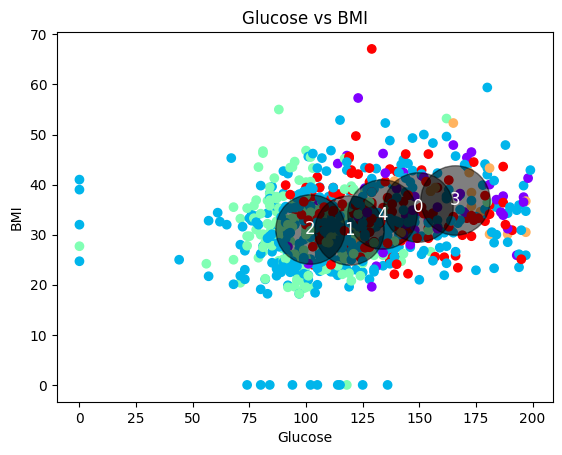

In [ ]:
centers = mkm.cluster_centers_

glucose = np.array(XD.iloc[:,1])
bmi = np.array(XD.iloc[:,5])

plt.figure()

plt.scatter(glucose, bmi, c=mkm.labels_, cmap="rainbow")
plt.scatter(centers[:,1], centers[:,5], c="black", s=2500, alpha=0.5)

plt.xlabel("Glucose")
plt.ylabel("BMI")

for i, c in enumerate(centers):
    plt.text(c[1], c[5], str(i), color='white', fontsize=12, ha='center', va='center')

plt.title("Glucose vs BMI")

plt.show()

**Análisis de Resultados**

En el gráfico se muestra la mayoría de los pacientes se concentran en valores de glucosa entre 90 y 160 y BMI entre 25 y 40.

Hay una superposición de algunos clusters, lo que quiere decir que algunos pacientes presentan características similares entre diferentes grupos. Aún así, el modelo identifica distintos perfiles según las variables mencionadas anteriormente.

Los clusters que se encuentran en valores más altos de las variables son los grupos de pacientes que son más propensos a tener diabetes, mientras los que tienen valores más bajos tiene una menor probabilidad de que les de diabetes.

**Conclusión de los 3 modelos**

Luego de utilizar los 3 modelos, se concluye que el modelo de Árbol de Decisión es el que tiene un mejor desempeño para este caso de diabetes, ya que en la Exactitud se obtuvo un 79.17% y los valores y resultados eran más fáciles de interpretar para clasificar los pacientes.

El modelo de Naive Bayes también tuvo un buen desempeño pero la Exactitud fue menor.

El modelo KMeans identificó los perfiles de los pacientes, pero no funciona como un modelo de clasificación directo, se enfoca más en la segmentación de grupos y sus gráficos son muy confusos.

Por lo anterior, el modelo de Árbol de decisión es el mejor ya que tiene una buena precisión para escoger los datos y una buena interpretación para brindar resultados.
